In [22]:
# Install semua module yang diperlukan
!pip install numpy pandas matplotlib seaborn tensorflow scikit-learn nltk keras

# Untuk NLTK data
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

print("Semua module selesai diinstall!")

Semua module selesai diinstall!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
# Import semua library
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import nltk

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, concatenate, Embedding, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("Semua library berhasil diimport!")
print(f"TensorFlow version: {tf.__version__}")

Semua library berhasil diimport!
TensorFlow version: 2.20.0


In [24]:
from google.colab import files

# Upload file CSV
print("Silakan upload file dataset_clickbait.csv Anda:")
uploaded = files.upload()

# Baca file yang diupload
for filename in uploaded.keys():
    df = pd.read_csv(filename)
    print(f"file '{filename}' berhasil dimuat!")

print(f"\n Informasi Dataset:")
print(f"   - Jumlah data: {len(df):,} baris")
print(f"   - Kolom: {list(df.columns)}")
print(f"\n 5 data pertama:")
print(df.head())

Silakan upload file dataset_clickbait.csv Anda:


Saving dataset_clickbait.csv to dataset_clickbait (2).csv
file 'dataset_clickbait (2).csv' berhasil dimuat!

 Informasi Dataset:
   - Jumlah data: 8,613 baris
   - Kolom: ['title', 'label', 'label_score']

 5 data pertama:
                                               title          label  \
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...  non-clickbait   
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...  non-clickbait   
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...      clickbait   
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...  non-clickbait   
4  MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...  non-clickbait   

   label_score  
0            0  
1            0  
2            1  
3            0  
4            0  


In [25]:
def extract_features(title):
    """
    Ekstraksi fitur-fitur dari judul berita:
    1. Jumlah tanda baca
    2. Jumlah huruf kapital
    3. Jumlah huruf kecil
    4. Jumlah angka
    5. Panjang teks
    6. Jumlah kata
    7. Rasio kata unik
    8. Rasio huruf kapital
    9. Jumlah tanda seru
    10. Jumlah tanda tanya
    """
    if not isinstance(title, str):
        title = str(title)

    # 1. Jumlah tanda baca
    punctuation = r'[!""#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]'
    num_punctuation = len(re.findall(punctuation, title))

    # 2. Jumlah huruf kapital
    num_uppercase = sum(1 for c in title if c.isupper())

    # 3. Jumlah huruf kecil
    num_lowercase = sum(1 for c in title if c.islower())

    # 4. Jumlah angka
    num_digits = sum(1 for c in title if c.isdigit())

    # 5. Panjang teks
    text_length = len(title)

    # 6. Jumlah kata
    num_words = len(title.split())

    # 7. Rasio kata unik
    unique_words = len(set(title.lower().split()))
    unique_words_ratio = unique_words / num_words if num_words > 0 else 0

    # 8. Rasio huruf kapital
    total_letters = num_uppercase + num_lowercase
    uppercase_ratio = num_uppercase / total_letters if total_letters > 0 else 0

    # 9. Jumlah tanda seru
    num_exclamation = title.count('!')

    # 10. Jumlah tanda tanya
    num_question = title.count('?')

    return {
        'num_punctuation': num_punctuation,
        'num_uppercase': num_uppercase,
        'num_lowercase': num_lowercase,
        'num_digits': num_digits,
        'text_length': text_length,
        'num_words': num_words,
        'unique_words_ratio': unique_words_ratio,
        'uppercase_ratio': uppercase_ratio,
        'num_exclamation': num_exclamation,
        'num_question': num_question
    }


print("EKSTRAKSI FITUR-FITUR BARU")


feature_list = []
for title in df['title']:
    feature_list.append(extract_features(title))

features_df = pd.DataFrame(feature_list)
df = pd.concat([df, features_df], axis=1)

print(f"\n Berhasil mengekstrak {len(features_df.columns)} fitur baru!")
print(f"\n Daftar fitur baru:")
for col in features_df.columns:
    print(f"   - {col}")

EKSTRAKSI FITUR-FITUR BARU

 Berhasil mengekstrak 10 fitur baru!

 Daftar fitur baru:
   - num_punctuation
   - num_uppercase
   - num_lowercase
   - num_digits
   - text_length
   - num_words
   - unique_words_ratio
   - uppercase_ratio
   - num_exclamation
   - num_question


In [30]:
# Setup stopwords dan stemmer
stop_words = set(stopwords.words('indonesian'))
additional_stops = {'yg', 'dgn', 'tdk', 'jd', 'utk', 'aja', 'sih', 'kok', 'banget',
                    'dong', 'ya', 'nih', 'deh', 'nya', 'dan', 'ini', 'itu', 'kan', 'saja'}
stop_words.update(additional_stops)
stemmer = PorterStemmer()

def preprocess_text(text):
    """Preprocessing teks untuk input neural network"""
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(token) for token in tokens
              if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)


print("PREPROCESSING TEKS")
print("_"*25)

df['processed_text'] = df['title'].apply(preprocess_text)

print(f"\n Preprocessing selesai!")
print(f"\n Contoh hasil:")
for i in range(3):
    print(f"\nOriginal  : {df['title'].iloc[i][:60]}...")
    print(f"Processed : {df['processed_text'].iloc[i][:60]}...")

PREPROCESSING TEKS
_________________________

 Preprocessing selesai!

 Contoh hasil:

Original  : Masuk Radar Pilwalkot Medan, Menantu Jokowi Bertemu DPW NasD...
Processed : masuk radar pilwalkot medan menantu jokowi bertemu dpw nasde...

Original  : Malaysia Sudutkan RI: Isu Kabut Asap hingga Invasi Babi...
Processed : malaysia sudutkan isu kabut asap invasi babi...

Original  : Viral! Driver Ojol di Bekasi Antar Pesanan Makanan Pakai Sep...
Processed : viral driver ojol bekasi pesanan makanan pakai sepeda...


In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. FITUR NUMERIK
numeric_features = ['num_punctuation', 'num_uppercase', 'num_lowercase', 'num_digits',
                    'text_length', 'num_words', 'unique_words_ratio', 'uppercase_ratio',
                    'num_exclamation', 'num_question']

X_numeric = df[numeric_features].values

# Standardisasi fitur numerik
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

#  2. FITUR TEKS
# Tokenisasi teks
MAX_FEATURES = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(df['processed_text'])
X_text_seq = tokenizer.texts_to_sequences(df['processed_text'])
X_text_pad = pad_sequences(X_text_seq, maxlen=MAX_LEN, padding='post', truncating='post')

#  3. LABEL
le = LabelEncoder()
y = le.fit_transform(df['label'])  # clickbait=1, non-clickbait=0

print("_"*60)
print("PERSIAPAN DATA")
print("_"*60)
print(f"\n Fitur Numerik:")
print(f"   - Shape: {X_numeric_scaled.shape}")
print(f"   - Fitur: {numeric_features}")
print(f"\n Fitur Teks:")
print(f"   - Shape: {X_text_pad.shape}")
print(f"   - Max length: {MAX_LEN}")
print(f"   - Vocabulary size: {min(MAX_FEATURES, len(tokenizer.word_index)+1)}")
print(f"\n Label:")
print(f"   - non-clickbait (0): {(y==0).sum():,}")
print(f"   - clickbait (1): {(y==1).sum():,}")

____________________________________________________________
PERSIAPAN DATA
____________________________________________________________

 Fitur Numerik:
   - Shape: (8613, 10)
   - Fitur: ['num_punctuation', 'num_uppercase', 'num_lowercase', 'num_digits', 'text_length', 'num_words', 'unique_words_ratio', 'uppercase_ratio', 'num_exclamation', 'num_question']

 Fitur Teks:
   - Shape: (8613, 100)
   - Max length: 100
   - Vocabulary size: 10000

 Label:
   - non-clickbait (0): 3,316
   - clickbait (1): 5,297


In [32]:
# Split data
X_num_train, X_num_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_numeric_scaled, X_text_pad, y, test_size=0.2, random_state=42, stratify=y
)

print("_"*60)
print("TRAIN TEST SPLIT")
print("_"*60)
print(f"\nTraining set: {len(y_train):,} data ({len(y_train)/len(y)*100:.1f}%)")
print(f"Testing set : {len(y_test):,} data ({len(y_test)/len(y)*100:.1f}%)")
print(f"\nDistribusi training:")
print(f"   - non-clickbait: {(y_train==0).sum():,}")
print(f"   - clickbait: {(y_train==1).sum():,}")

____________________________________________________________
TRAIN TEST SPLIT
____________________________________________________________

Training set: 6,890 data (80.0%)
Testing set : 1,723 data (20.0%)

Distribusi training:
   - non-clickbait: 2,653
   - clickbait: 4,237


In [33]:
# Hitung class weight untuk mengatasi imbalance
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("_"*60)
print("PEMBOBOTAN CLASS (CLASS WEIGHT)")
print("_"*60)
print(f"\nClass weight yang dihitung:")
print(f"   - non-clickbait (0): {class_weights[0]:.4f}")
print(f"   - clickbait (1): {class_weights[1]:.4f}")

____________________________________________________________
PEMBOBOTAN CLASS (CLASS WEIGHT)
____________________________________________________________

Class weight yang dihitung:
   - non-clickbait (0): 1.2985
   - clickbait (1): 0.8131


In [34]:
# PARAMETER
VOCAB_SIZE = min(MAX_FEATURES, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128
MAX_SEQUENCE_LENGTH = MAX_LEN
LSTM_UNITS = 64
DROPOUT_RATE = 0.3

#  INPUT 1: TEKS (LSTM)
text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name='text_input')
embedding_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
lstm_layer = Bidirectional(LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, return_sequences=False))(embedding_layer)
text_dropout = Dropout(DROPOUT_RATE)(lstm_layer)
text_output = Dense(32, activation='relu')(text_dropout)

#  INPUT 2: FITUR NUMERIK
numeric_input = Input(shape=(X_num_train.shape[1],), name='numeric_input')
numeric_dense = Dense(32, activation='relu')(numeric_input)
numeric_dropout = Dropout(DROPOUT_RATE)(numeric_dense)
numeric_output = Dense(16, activation='relu')(numeric_dropout)

#  GABUNGKAN
concat = concatenate([text_output, numeric_output])

#  LAYER FULLY CONNECTED
hidden1 = Dense(64, activation='relu')(concat)
dropout1 = Dropout(DROPOUT_RATE)(hidden1)
hidden2 = Dense(32, activation='relu')(dropout1)
dropout2 = Dropout(DROPOUT_RATE)(hidden2)
hidden3 = Dense(16, activation='relu')(dropout2)

#  OUTPUT
output = Dense(1, activation='sigmoid', name='output')(hidden3)

#  BUILD MODEL
model = Model(inputs=[text_input, numeric_input], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("_"*60)
print("ARSITEKTUR MULTI INPUT LSTM NEURAL NETWORK")
print("_"*60)
model.summary()

# Visualisasi model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
print("\n Arsitektur model disimpan ke 'model_architecture.png'")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


____________________________________________________________
ARSITEKTUR MULTI INPUT LSTM NEURAL NETWORK
____________________________________________________________


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        352 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      3,136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,389,585 (5.30 MB)

 Trainable params: 1,389,585 (5.30 MB)

 Non-trainable params: 0 (0.00 B)


 Arsitektur model disimpan ke 'model_architecture.png'


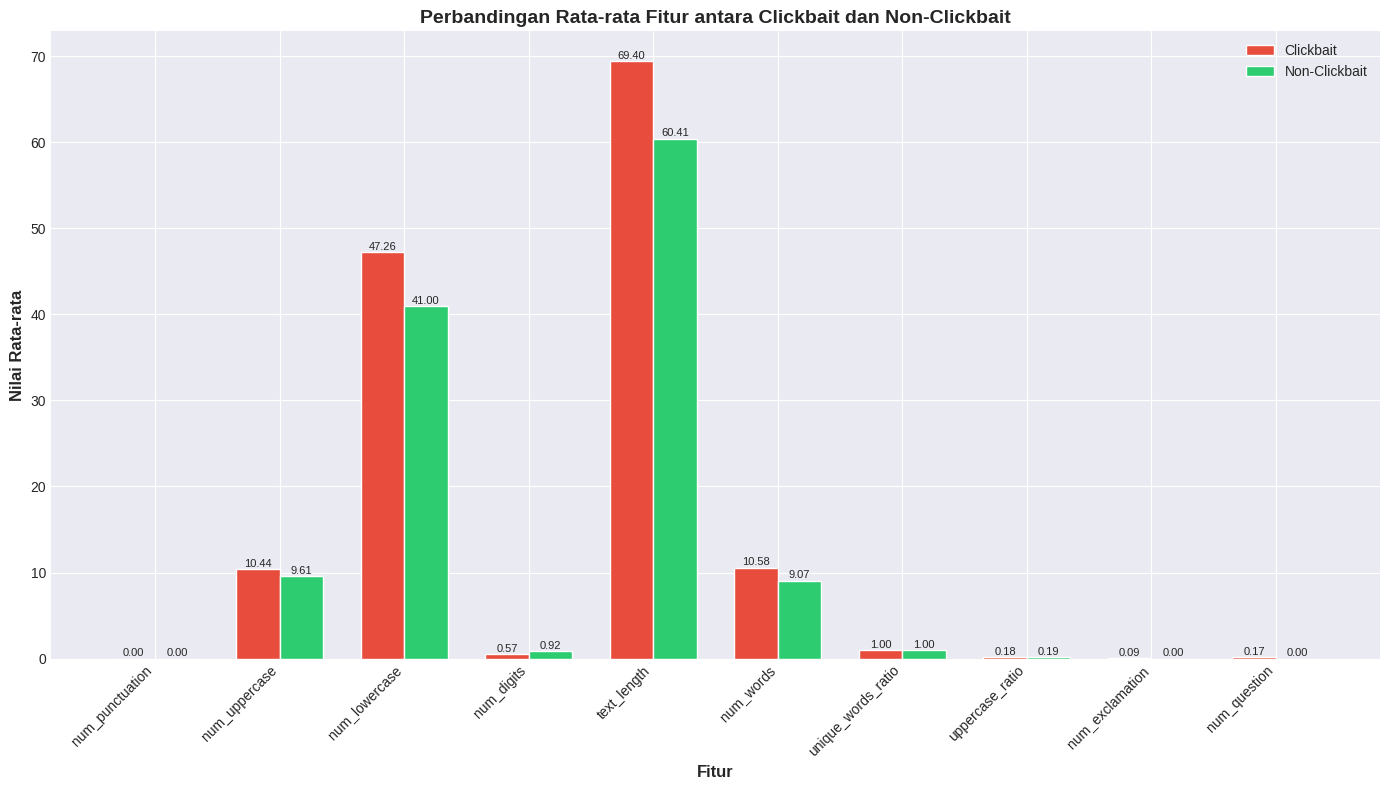

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style grafik
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Daftar fitur yang akan divisualisasikan
fitur_list = ['num_punctuation', 'num_uppercase', 'num_lowercase', 'num_digits',
              'text_length', 'num_words', 'unique_words_ratio', 'uppercase_ratio',
              'num_exclamation', 'num_question']


# GRAFIK 1: Perbandingan Rata-rata Fitur

fig, ax = plt.subplots(figsize=(14, 8))

# Hitung rata-rata per label
cb_mean = df[df['label']=='clickbait'][fitur_list].mean()
ncb_mean = df[df['label']=='non-clickbait'][fitur_list].mean()

x = np.arange(len(fitur_list))
width = 0.35

bars1 = ax.bar(x - width/2, cb_mean, width, label='Clickbait', color='#e74c3c')
bars2 = ax.bar(x + width/2, ncb_mean, width, label='Non-Clickbait', color='#2ecc71')

ax.set_xlabel('Fitur', fontsize=12, fontweight='bold')
ax.set_ylabel('Nilai Rata-rata', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Rata-rata Fitur antara Clickbait dan Non-Clickbait', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fitur_list, rotation=45, ha='right')
ax.legend()

# Tambahkan nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_fitur.png', dpi=150)
plt.show()

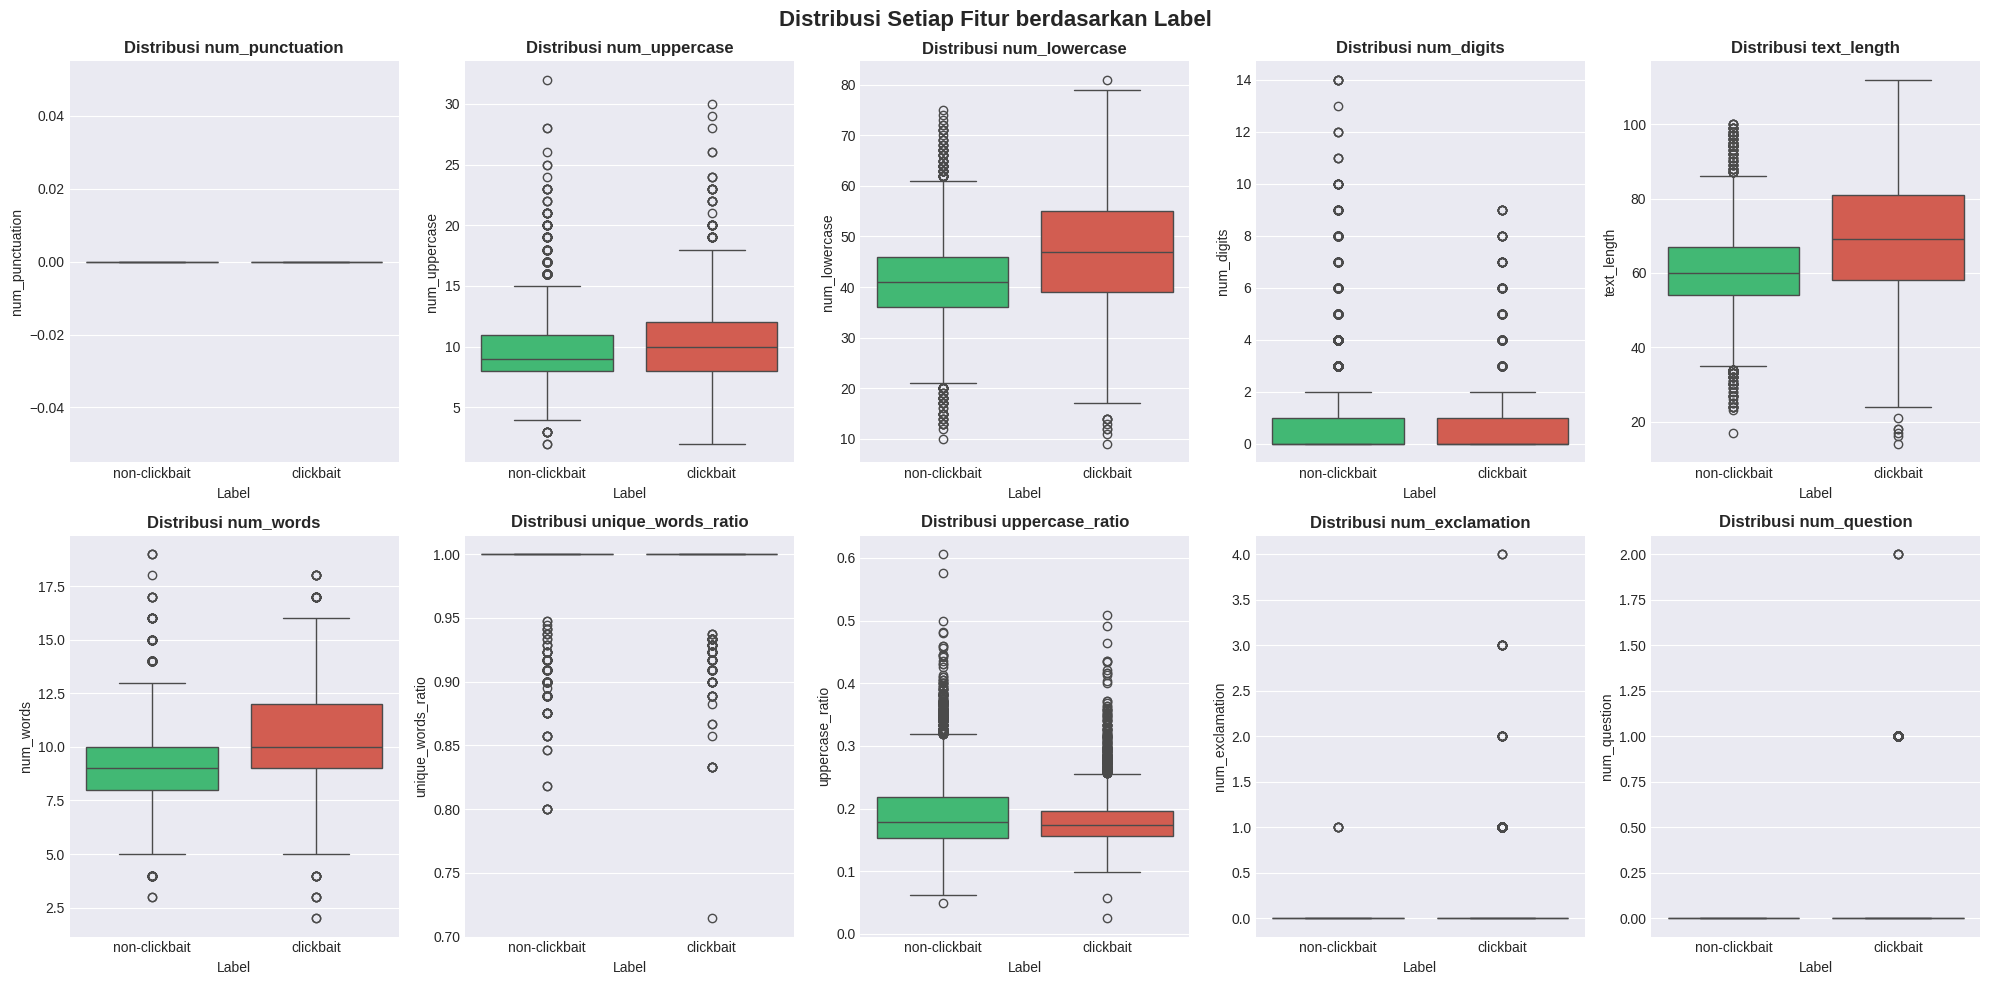

In [37]:
# GRAFIK 2: Distribusi Setiap Fitur (Boxplot) - TANPA WARNING

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, fitur in enumerate(fitur_list):
    sns.boxplot(data=df, x='label', y=fitur, ax=axes[i], hue='label',
                palette={'clickbait': '#e74c3c', 'non-clickbait': '#2ecc71'}, legend=False)
    axes[i].set_title(f'Distribusi {fitur}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Label', fontsize=10)
    axes[i].set_ylabel(fitur, fontsize=10)

plt.suptitle('Distribusi Setiap Fitur berdasarkan Label', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_fitur_boxplot.png', dpi=150)
plt.show()

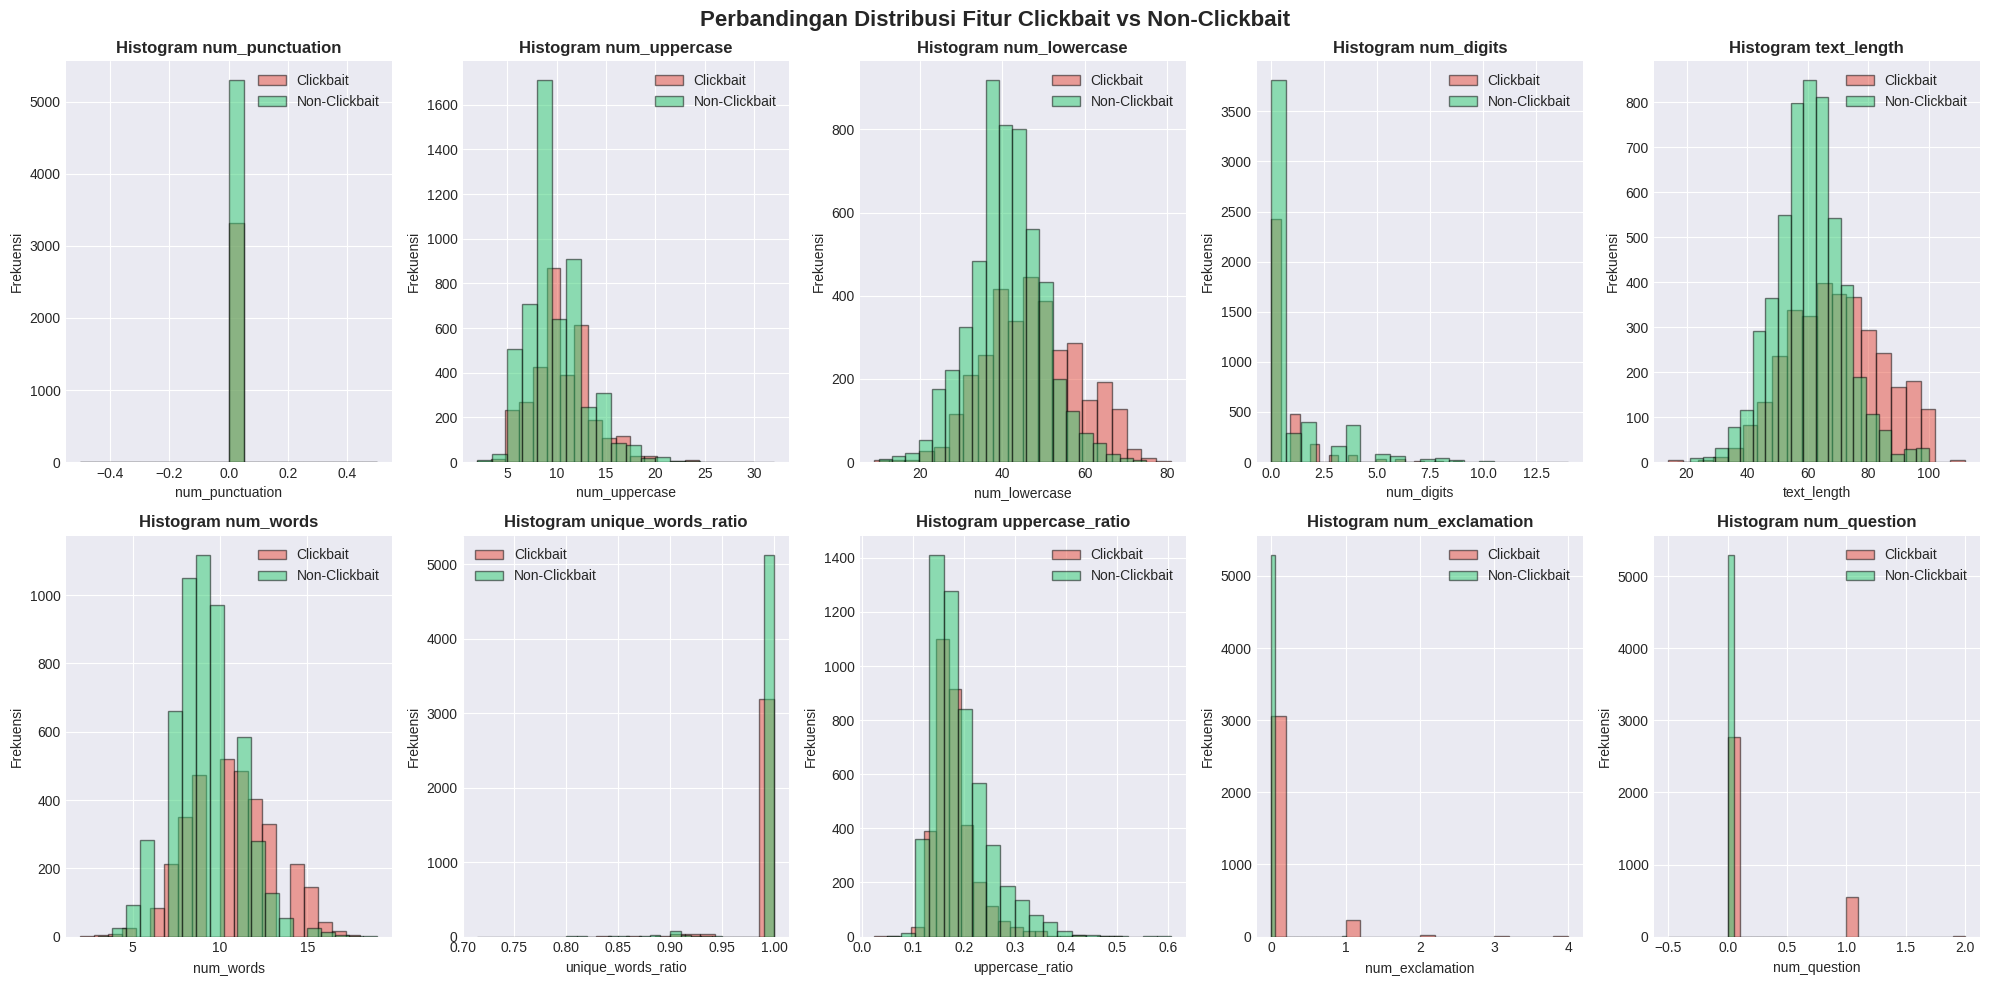

In [38]:
# GRAFIK 3: Histogram Perbandingan Clickbait vs Non-Clickbait

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, fitur in enumerate(fitur_list):
    # Pisahkan data berdasarkan label
    cb_data = df[df['label']=='clickbait'][fitur]
    ncb_data = df[df['label']=='non-clickbait'][fitur]

    # Plot histogram
    axes[i].hist(cb_data, bins=20, alpha=0.5, label='Clickbait', color='#e74c3c', edgecolor='black')
    axes[i].hist(ncb_data, bins=20, alpha=0.5, label='Non-Clickbait', color='#2ecc71', edgecolor='black')
    axes[i].set_title(f'Histogram {fitur}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(fitur, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].legend()

plt.suptitle('Perbandingan Distribusi Fitur Clickbait vs Non-Clickbait', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_fitur.png', dpi=150)
plt.show()

NameError: name 'history' is not defined

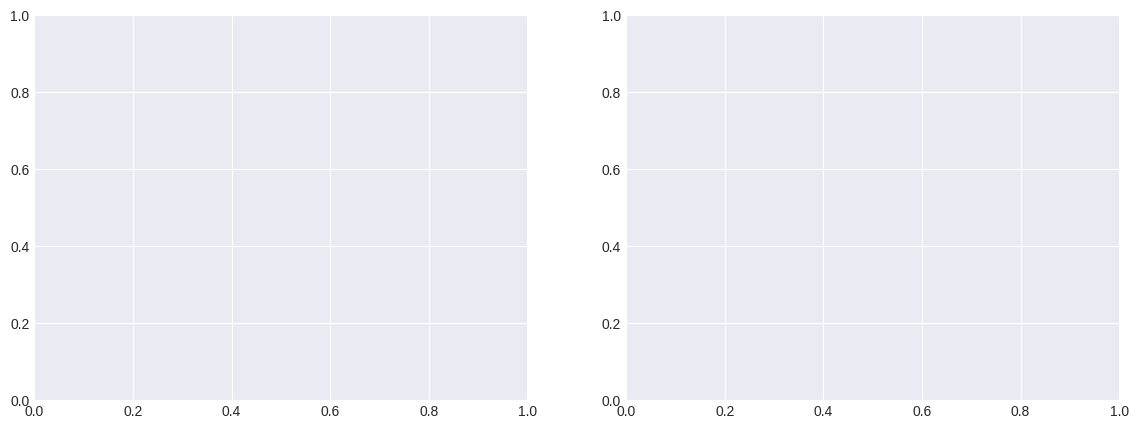

In [39]:
# GRAFIK 4: Training History (Loss dan Accuracy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Loss (Sumbu X: Epoch, Sumbu Y: Loss)
axes[0].plot(history.history['loss'], label='Training Loss', marker='o', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Model Loss selama Training', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafik Accuracy (Sumbu X: Epoch, Sumbu Y: Accuracy)
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Model Accuracy selama Training', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_loss_accuracy.png', dpi=150)
plt.show()

In [40]:
#  PARAMETER
VOCAB_SIZE = min(MAX_FEATURES, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128
MAX_SEQUENCE_LENGTH = MAX_LEN
LSTM_UNITS = 64
DROPOUT_RATE = 0.3

#  INPUT 1: TEKS (LSTM)
text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name='text_input')
embedding_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
lstm_layer = Bidirectional(LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, return_sequences=False))(embedding_layer)
text_dropout = Dropout(DROPOUT_RATE)(lstm_layer)
text_output = Dense(32, activation='relu')(text_dropout)

#  INPUT 2: FITUR NUMERIK
numeric_input = Input(shape=(X_num_train.shape[1],), name='numeric_input')
numeric_dense = Dense(32, activation='relu')(numeric_input)
numeric_dropout = Dropout(DROPOUT_RATE)(numeric_dense)
numeric_output = Dense(16, activation='relu')(numeric_dropout)

#  GABUNGKAN
concat = concatenate([text_output, numeric_output])

#  LAYER FULLY CONNECTED
hidden1 = Dense(64, activation='relu')(concat)
dropout1 = Dropout(DROPOUT_RATE)(hidden1)
hidden2 = Dense(32, activation='relu')(dropout1)
dropout2 = Dropout(DROPOUT_RATE)(hidden2)
hidden3 = Dense(16, activation='relu')(dropout2)

#  OUTPUT
output = Dense(1, activation='sigmoid', name='output')(hidden3)

#  BUILD MODEL
model = Model(inputs=[text_input, numeric_input], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("_"*60)
print("ARSITEKTUR MULTI INPUT LSTM NEURAL NETWORK")
print("_"*60)
model.summary()

____________________________________________________________
ARSITEKTUR MULTI INPUT LSTM NEURAL NETWORK
____________________________________________________________


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 128)  │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │        352 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      4,128 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        528 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      3,136 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        528 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,389,585 (5.30 MB)

 Trainable params: 1,389,585 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Training
print("_"*60)
print("TRAINING MULTI INPUT LSTM NEURAL NETWORK")
print("_"*60)

history = model.fit(
    [X_text_train, X_num_train],
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n Training selesai!")

____________________________________________________________
TRAINING MULTI INPUT LSTM NEURAL NETWORK
____________________________________________________________
Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 155ms/step - accuracy: 0.7155 - loss: 0.5626 - precision_1: 0.7796 - recall_1: 0.7468 - val_accuracy: 0.8527 - val_loss: 0.3972 - val_precision_1: 0.8729 - val_recall_1: 0.8942
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.8975 - loss: 0.2894 - precision_1: 0.9167 - recall_1: 0.9159 - val_accuracy: 0.8483 - val_loss: 0.3802 - val_precision_1: 0.8754 - val_recall_1: 0.8826
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 28s 162ms/step - accuracy: 0.9514 - loss: 0.1497 - precision_1: 0.9617 - recall_1: 0.9588 - val_accuracy: 0.8462 - val_loss: 0.4314 - val_precision_1: 0.8866 - val_recall_1: 0.8640
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.9686 - loss: 0.0894 - precision_1: 0.9814 - recall_1: 0.9671 - val_accuracy: 0.8266 - val_loss: 0.7238 - 

54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step
____________________________________________________________
EVALUASI MODEL
____________________________________________________________

 Akurasi Model: 0.8624 (86.24%)

 Classification Report:
               precision    recall  f1-score   support

non-clickbait       0.82      0.82      0.82       663
    clickbait       0.89      0.89      0.89      1060

     accuracy                           0.86      1723
    macro avg       0.85      0.86      0.85      1723
 weighted avg       0.86      0.86      0.86      1723



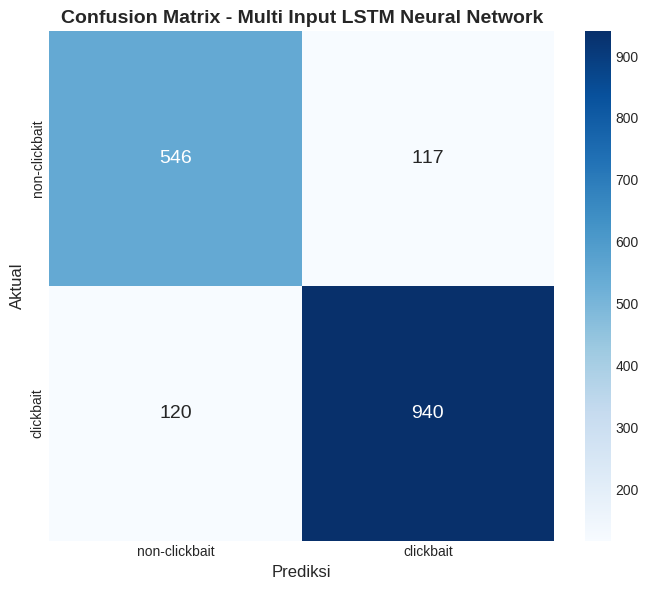

In [42]:
# Prediksi
y_pred_prob = model.predict([X_text_test, X_num_test])
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrik
accuracy = accuracy_score(y_test, y_pred)

print("_"*60)
print("EVALUASI MODEL")
print("_"*60)
print(f"\n Akurasi Model: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['non-clickbait', 'clickbait']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-clickbait', 'clickbait'],
            yticklabels=['non-clickbait', 'clickbait'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Multi Input LSTM Neural Network', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

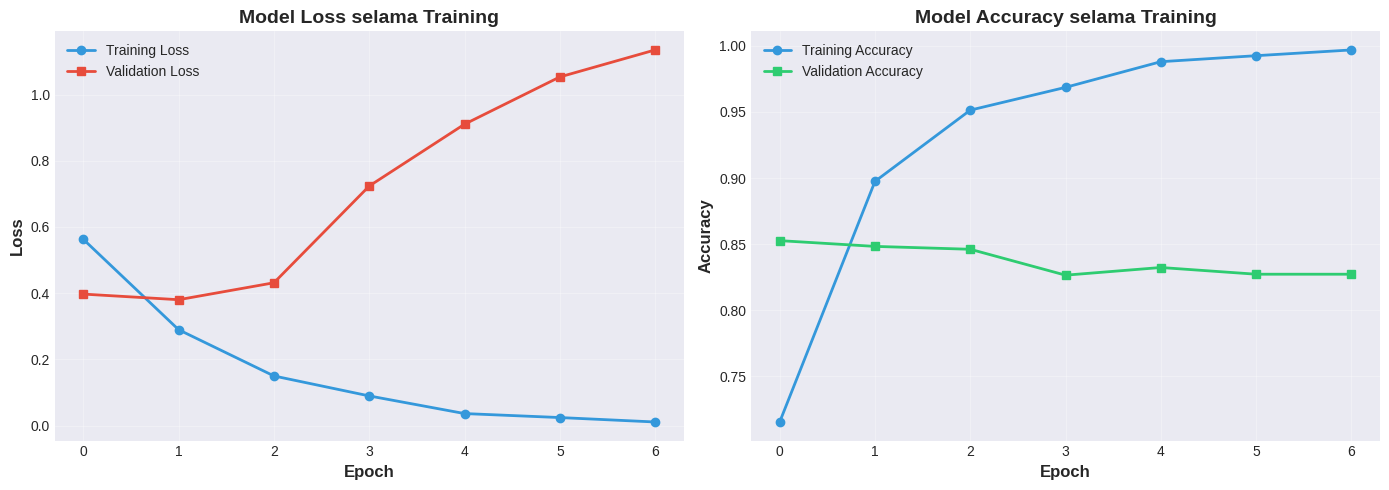

In [43]:

# GRAFIK 4: Training History (Loss dan Accuracy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Loss (Sumbu X: Epoch, Sumbu Y: Loss)
axes[0].plot(history.history['loss'], label='Training Loss', marker='o', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Model Loss selama Training', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafik Accuracy (Sumbu X: Epoch, Sumbu Y: Accuracy)
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Model Accuracy selama Training', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_loss_accuracy.png', dpi=150)
plt.show()